
PERCEPTRON TRAINING
Epoch 1: Weights = [0.1 0.1], Bias = 0.10, Errors = 1
Epoch 2: Weights = [0.2 0.1], Bias = 0.00, Errors = 3
Epoch 3: Weights = [0.2 0.1], Bias = -0.10, Errors = 3
Epoch 4: Weights = [0.2 0.2], Bias = -0.10, Errors = 2
Epoch 5: Weights = [0.2 0.1], Bias = -0.20, Errors = 1
Epoch 6: Weights = [0.2 0.1], Bias = -0.20, Errors = 0

Perceptron converged!
Converged after 6 epochs.

FINAL PERCEPTRON PARAMETERS
Weight 1: 0.2
Weight 2: 0.1
Bias: -0.2

AND GATE PREDICTION
Enter X1 (0 or 1): 1
Enter X2 (0 or 1): 1

Weighted Sum: 0.10000000000000003
Predicted Output: 1


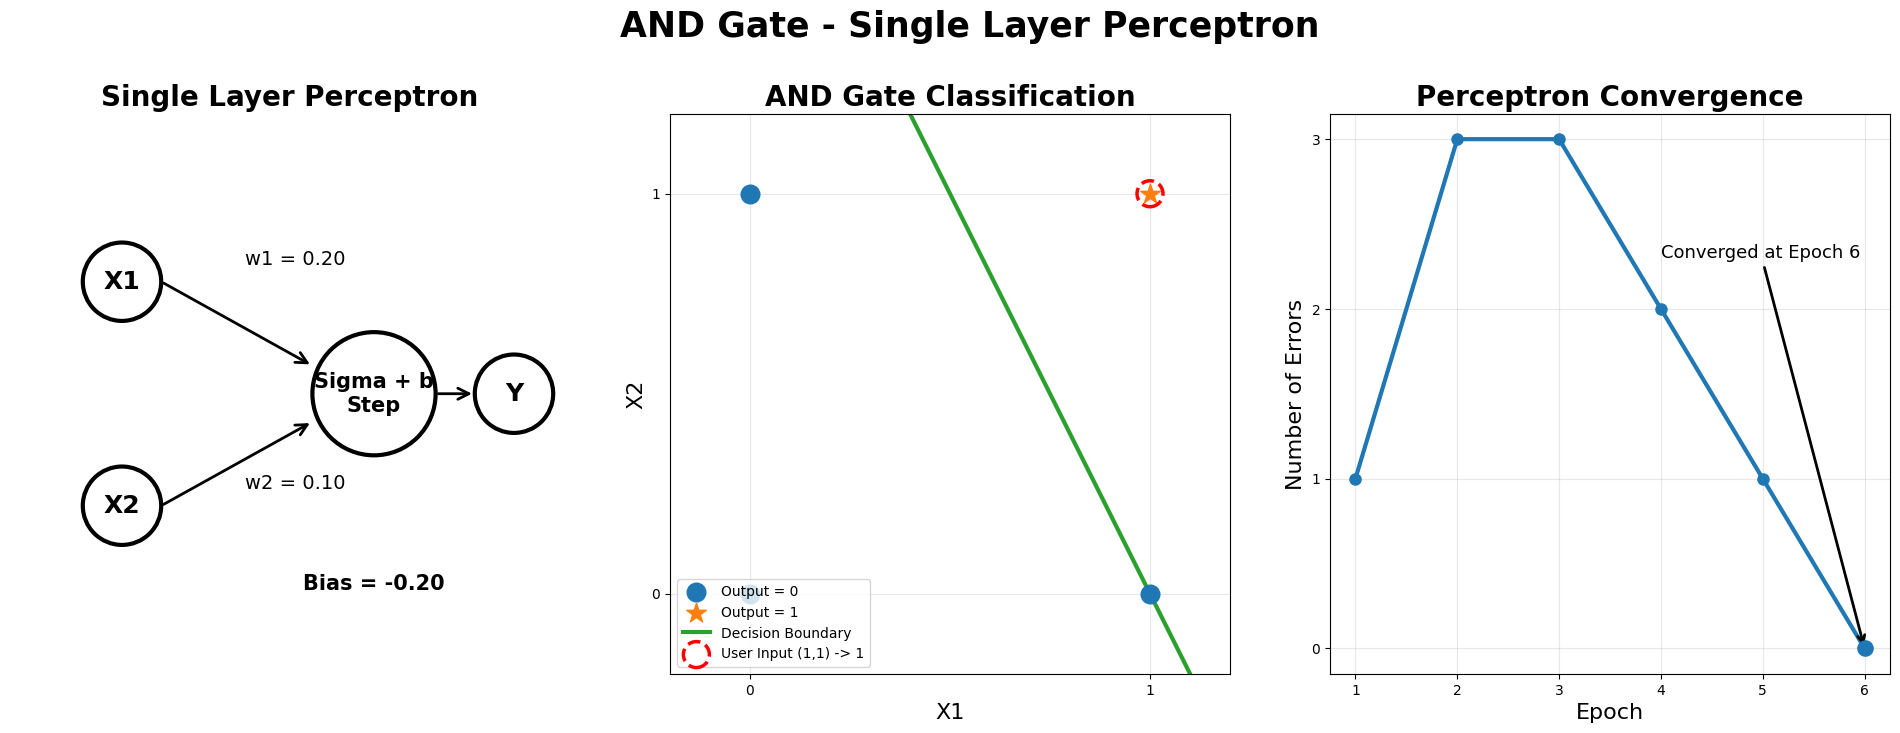

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# 1. Corrected dataset initialization for AND gate
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 0, 0, 1])
weights = np.array([0.0, 0.0])
bias = 0.0

learning_rate = 0.1
max_epochs = 100

def activation(z):
    if z > 0:
        return 1
    else:
        return 0

error_history = []

print("\n==============================")
print("PERCEPTRON TRAINING")
print("==============================")

for epoch in range(max_epochs):
    errors = 0

    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        prediction = activation(z)
        error = y[i] - prediction

        if error != 0:
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error
            errors += 1

    error_history.append(errors)

    print(
        f"Epoch {epoch + 1}: "
        f"Weights = {weights}, "
        f"Bias = {bias:.2f}, "
        f"Errors = {errors}"
    )

    if errors == 0:
        print("\nPerceptron converged!")
        print(f"Converged after {epoch + 1} epochs.")
        break
else:
    print("\nPerceptron did not converge within the maximum epochs.")

print("\n==============================")
print("FINAL PERCEPTRON PARAMETERS")
print("==============================")
print("Weight 1:", weights[0])
print("Weight 2:", weights[1])
print("Bias:", bias)

print("\n==============================")
print("AND GATE PREDICTION")
print("==============================")

while True:
    try:
        x1 = float(input("Enter X1 (0 or 1): "))
        x2 = float(input("Enter X2 (0 or 1): "))
        if x1 in [0, 1] and x2 in [0, 1]:
            break
        print("Please enter only 0 or 1.")
    except ValueError:
        print("Invalid input.")

user_input = np.array([x1, x2])
z_user = np.dot(user_input, weights) + bias
user_prediction = activation(z_user)

print("\nWeighted Sum:", z_user)
print("Predicted Output:", user_prediction)

fig = plt.figure(figsize=(20, 8))

# Subplot 1: Perceptron Architecture Diagram
ax1 = fig.add_axes([0.02, 0.15, 0.28, 0.70])
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis("off")
ax1.set_title("Single Layer Perceptron", fontsize=20, fontweight="bold")

input_positions = [(2, 7), (2, 3)]
input_labels = ["X1", "X2"]

for (x, y_pos), label in zip(input_positions, input_labels):
    circle = Circle((x, y_pos), 0.7, fill=False, linewidth=3)
    ax1.add_patch(circle)
    ax1.text(x, y_pos, label, ha="center", va="center", fontsize=18, fontweight="bold")

ax1.text(4.2, 7.3, f"w1 = {weights[0]:.2f}", fontsize=14)
ax1.text(4.2, 3.3, f"w2 = {weights[1]:.2f}", fontsize=14)

neuron = Circle((6.5, 5), 1.1, fill=False, linewidth=3)
ax1.add_patch(neuron)
ax1.text(6.5, 5, "Sigma + b\nStep", ha="center", va="center", fontsize=15, fontweight="bold")

output = Circle((9, 5), 0.7, fill=False, linewidth=3)
ax1.add_patch(output)
ax1.text(9, 5, "Y", ha="center", va="center", fontsize=18, fontweight="bold")

arrow1 = FancyArrowPatch((2.7, 7), (5.4, 5.5), arrowstyle="->", mutation_scale=20, linewidth=2)
arrow2 = FancyArrowPatch((2.7, 3), (5.4, 4.5), arrowstyle="->", mutation_scale=20, linewidth=2)
arrow3 = FancyArrowPatch((7.6, 5), (8.3, 5), arrowstyle="->", mutation_scale=20, linewidth=2)

ax1.add_patch(arrow1)
ax1.add_patch(arrow2)
ax1.add_patch(arrow3)

ax1.text(6.5, 1.5, f"Bias = {bias:.2f}", ha="center", fontsize=15, fontweight="bold")

# Subplot 2: AND Gate Classification & Decision Boundary
ax2 = fig.add_axes([0.35, 0.15, 0.28, 0.70])

class_0 = X[y == 0]
class_1 = X[y == 1]

ax2.scatter(class_0[:, 0], class_0[:, 1], s=180, marker="o", label="Output = 0", zorder=3)
ax2.scatter(class_1[:, 0], class_1[:, 1], s=220, marker="*", label="Output = 1", zorder=3)

x_boundary = np.linspace(-0.2, 1.2, 100)

if abs(weights[1]) > 1e-10:
    y_boundary = -(weights[0] * x_boundary + bias) / weights[1]
    ax2.plot(x_boundary, y_boundary, linewidth=3, label="Decision Boundary", color="tab:green", zorder=2)
elif abs(weights[0]) > 1e-10:
    x_vertical = -bias / weights[0]
    ax2.axvline(x=x_vertical, linewidth=3, label="Decision Boundary", color="tab:green", zorder=2)

ax2.scatter(
    x1, x2, s=350, facecolors="none", edgecolors="red", linewidths=2.5, linestyle="--",
    label=f"User Input ({x1:.0f},{x2:.0f}) -> {user_prediction}", zorder=4
)

ax2.set_title("AND Gate Classification", fontsize=20, fontweight="bold")
ax2.set_xlabel("X1", fontsize=16)
ax2.set_ylabel("X2", fontsize=16)
ax2.set_xlim(-0.2, 1.2)
ax2.set_ylim(-0.2, 1.2)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)  # Fixed missing parenthesis here
ax2.legend(fontsize=10, loc="lower left")

# Subplot 3: Perceptron Convergence
ax3 = fig.add_axes([0.68, 0.15, 0.28, 0.70])

epochs = np.arange(1, len(error_history) + 1)

ax3.plot(epochs, error_history, marker="o", linewidth=3, markersize=8)
ax3.set_title("Perceptron Convergence", fontsize=20, fontweight="bold")
ax3.set_xlabel("Epoch", fontsize=16)
ax3.set_ylabel("Number of Errors", fontsize=16)
ax3.set_xticks(epochs)
ax3.set_yticks(range(0, max(error_history) + 1))
ax3.grid(True, alpha=0.3)

if error_history[-1] == 0:
    convergence_epoch = len(error_history)
    ax3.scatter(convergence_epoch, 0, s=120, zorder=5)
    ax3.annotate(
        f"Converged at Epoch {convergence_epoch}",
        xy=(convergence_epoch, 0),
        xytext=(max(1, convergence_epoch - 2), max(error_history) * 0.6 + 0.5),
        fontsize=13,
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )

fig.suptitle("AND Gate - Single Layer Perceptron", fontsize=25, fontweight="bold")

plt.show()

Epoch 1: Weights = [-0.1  0. ], Bias = 0.00, Errors = 2
Epoch 2: Weights = [-0.1  0. ], Bias = 0.10, Errors = 3
Epoch 3: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 4: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 5: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 6: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 7: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 8: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 9: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 10: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 11: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 12: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 13: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 14: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 15: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 16: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 17: Weights = [-0.1  0. ], Bias = 0.10, Errors = 4
Epoch 18: Weights = [-0.1  0. ], Bias = 

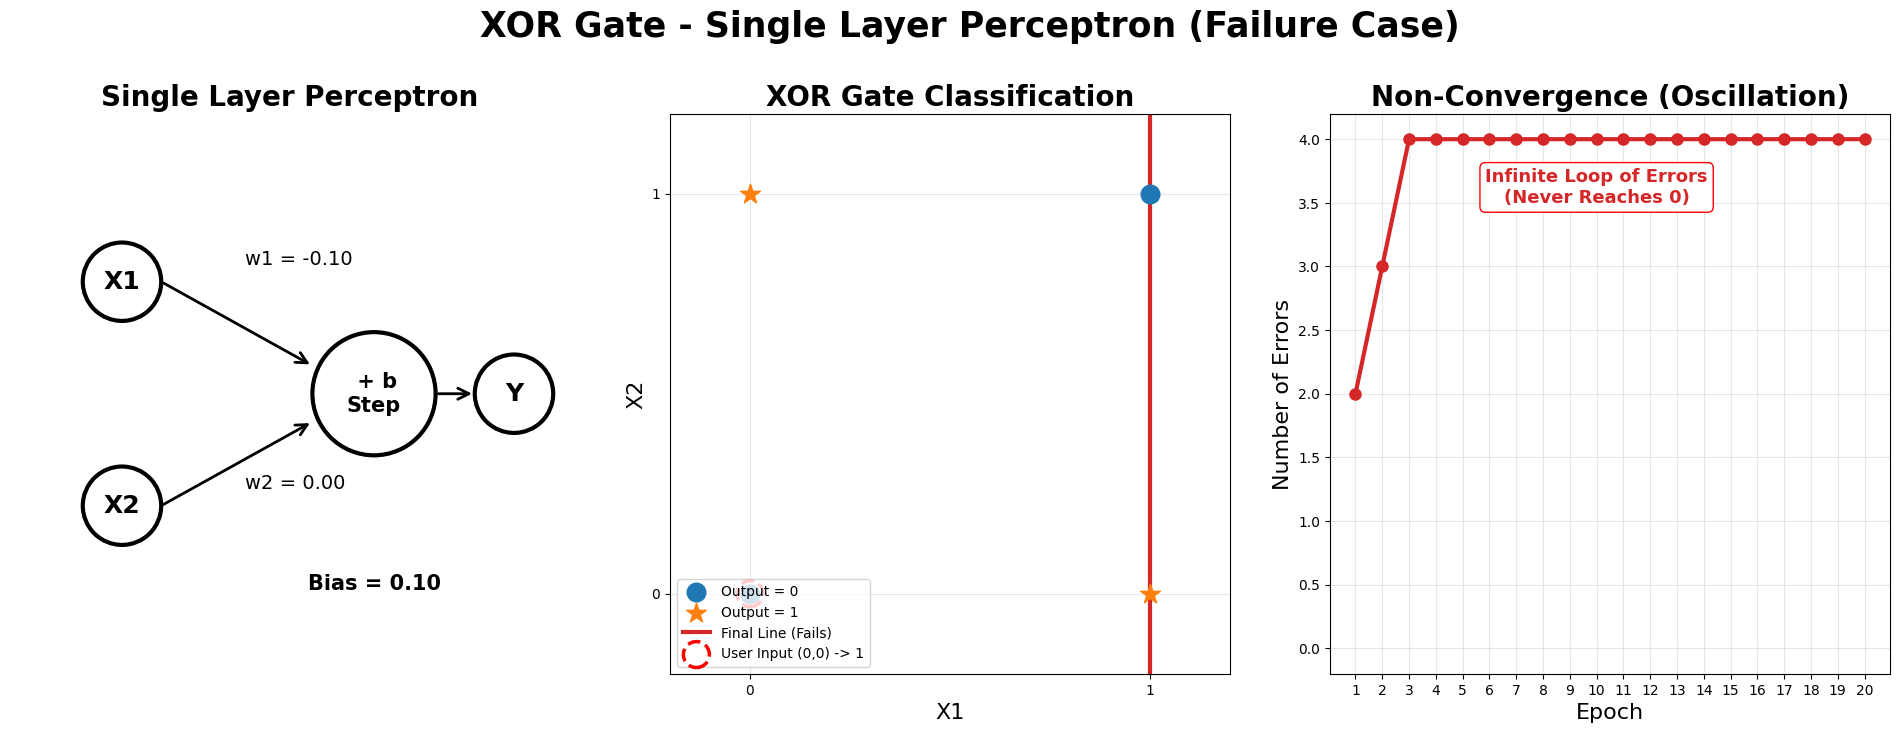

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# =========================================================
# 1. XOR GATE TRAINING DATA
# =========================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 1, 1, 0])

# =========================================================
# 2. INITIALIZE WEIGHTS AND BIAS
# =========================================================

weights = np.array([0.0, 0.0])
bias = 0.0

learning_rate = 0.1
max_epochs = 20

# =========================================================
# 3. STEP ACTIVATION FUNCTION
# =========================================================

def activation(z):
    return 1 if z > 0 else 0

# =========================================================
# 4. PERCEPTRON TRAINING
# =========================================================

error_history = []

for epoch in range(max_epochs):
    errors = 0
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        prediction = activation(z)
        error = y[i] - prediction

        if error != 0:
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error
            errors += 1

    error_history.append(errors)

    print(
        f"Epoch {epoch + 1}: "
        f"Weights = {weights}, "
        f"Bias = {bias:.2f}, "
        f"Errors = {errors}"
    )

    if errors == 0:
        print("\nPerceptron converged!")
        break
else:
    print("\nPerceptron did NOT converge within the maximum epochs!")

# =========================================================
# 5. USER INPUT
# =========================================================

print("\n==============================")
print("XOR GATE PREDICTION")
print("==============================")

x1 = float(input("Enter X1 (0 or 1): "))
x2 = float(input("Enter X2 (0 or 1): "))

user_input = np.array([x1, x2])
z_user = np.dot(user_input, weights) + bias
user_prediction = activation(z_user)

# =========================================================
# 6. CREATE FIGURE
# =========================================================

fig = plt.figure(figsize=(20, 8))

# =========================================================
# 7. PERCEPTRON ARCHITECTURE DIAGRAM
# =========================================================

ax1 = fig.add_axes([0.02, 0.15, 0.28, 0.7])
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis("off")
ax1.set_title("Single Layer Perceptron", fontsize=20, fontweight="bold")

input_positions = [(2, 7), (2, 3)]
input_labels = ["X1", "X2"]

for (x, y_pos), label in zip(input_positions, input_labels):
    circle = Circle((x, y_pos), 0.7, fill=False, linewidth=3)
    ax1.add_patch(circle)
    ax1.text(x, y_pos, label, ha="center", va="center", fontsize=18, fontweight="bold")

ax1.text(4.2, 7.3, f"w1 = {weights[0]:.2f}", fontsize=14)
ax1.text(4.2, 3.3, f"w2 = {weights[1]:.2f}", fontsize=14)

neuron = Circle((6.5, 5), 1.1, fill=False, linewidth=3)
ax1.add_patch(neuron)
ax1.text(6.5, 5, " + b\nStep", ha="center", va="center", fontsize=15, fontweight="bold")

output = Circle((9, 5), 0.7, fill=False, linewidth=3)
ax1.add_patch(output)
ax1.text(9, 5, "Y", ha="center", va="center", fontsize=18, fontweight="bold")

arrow1 = FancyArrowPatch((2.7, 7), (5.4, 5.5), arrowstyle="->", mutation_scale=20, linewidth=2)
arrow2 = FancyArrowPatch((2.7, 3), (5.4, 4.5), arrowstyle="->", mutation_scale=20, linewidth=2)
arrow3 = FancyArrowPatch((7.6, 5), (8.3, 5), arrowstyle="->", mutation_scale=20, linewidth=2)

ax1.add_patch(arrow1)
ax1.add_patch(arrow2)
ax1.add_patch(arrow3)

ax1.text(6.5, 1.5, f"Bias = {bias:.2f}", ha="center", fontsize=15, fontweight="bold")

# =========================================================
# 8. XOR GATE CLASSIFICATION GRAPH
# =========================================================

ax2 = fig.add_axes([0.35, 0.15, 0.28, 0.7])

class_0 = X[y == 0]
class_1 = X[y == 1]

ax2.scatter(class_0[:, 0], class_0[:, 1], s=180, marker="o", label="Output = 0", zorder=3)
ax2.scatter(class_1[:, 0], class_1[:, 1], s=220, marker="*", label="Output = 1", zorder=3)

# =========================================================
# 9. FINAL DECISION BOUNDARY
# =========================================================

x_boundary = np.linspace(-0.2, 1.2, 100)

if abs(weights[1]) > 1e-10:
    y_boundary = -(weights[0] * x_boundary + bias) / weights[1]
    ax2.plot(x_boundary, y_boundary, linewidth=3, label="Final Line (Fails)", color="tab:red", zorder=2)
elif abs(weights[0]) > 1e-10:
    x_vert = -bias / weights[0]
    ax2.axvline(x=x_vert, linewidth=3, label="Final Line (Fails)", color="tab:red", zorder=2)

# =========================================================
# 10. MARK USER INPUT
# =========================================================

ax2.scatter(
    x1, x2, s=350, facecolors="none", edgecolors="red", linewidths=2.5, linestyle="--",
    label=f"User Input ({x1:.0f},{x2:.0f}) -> {user_prediction}", zorder=4
)

# =========================================================
# 11. GRAPH FORMATTING
# =========================================================

ax2.set_title("XOR Gate Classification", fontsize=20, fontweight="bold")
ax2.set_xlabel("X1", fontsize=16)
ax2.set_ylabel("X2", fontsize=16)
ax2.set_xlim(-0.2, 1.2)
ax2.set_ylim(-0.2, 1.2)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, loc="lower left")

# =========================================================
# 12. CONVERGENCE GRAPH
# =========================================================

ax3 = fig.add_axes([0.68, 0.15, 0.28, 0.7])

epochs = range(1, len(error_history) + 1)

ax3.plot(epochs, error_history, marker="o", color="tab:red", linewidth=3, markersize=8)
ax3.set_title("Non-Convergence (Oscillation)", fontsize=20, fontweight="bold")
ax3.set_xlabel("Epoch", fontsize=16)
ax3.set_ylabel("Number of Errors", fontsize=16)
ax3.set_xticks(list(epochs))
ax3.set_ylim(-0.2, 4.2)
ax3.grid(True, alpha=0.3)

# =========================================================
# 13. ANNOTATE NON-CONVERGENCE
# =========================================================

ax3.text(
    max(epochs) / 2, 3.5,
    "Infinite Loop of Errors\n(Never Reaches 0)",
    fontsize=13, fontweight="bold", color="tab:red", ha="center",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="red")
)

# =========================================================
# 14. MAIN TITLE
# =========================================================

fig.suptitle("XOR Gate - Single Layer Perceptron (Failure Case)", fontsize=25, fontweight="bold")

plt.show()

Epoch 1: Weights = [0.  0.1], Bias = 0.10, Errors = 1
Epoch 2: Weights = [0.1 0.1], Bias = 0.10, Errors = 2
Epoch 3: Weights = [0.1 0.1], Bias = 0.00, Errors = 1
Epoch 4: Weights = [0.1 0.1], Bias = 0.00, Errors = 0

Perceptron converged!
Converged after 4 epochs.

OR GATE PREDICTION
Enter X1 (0 or 1): 0
Enter X2 (0 or 1): 1


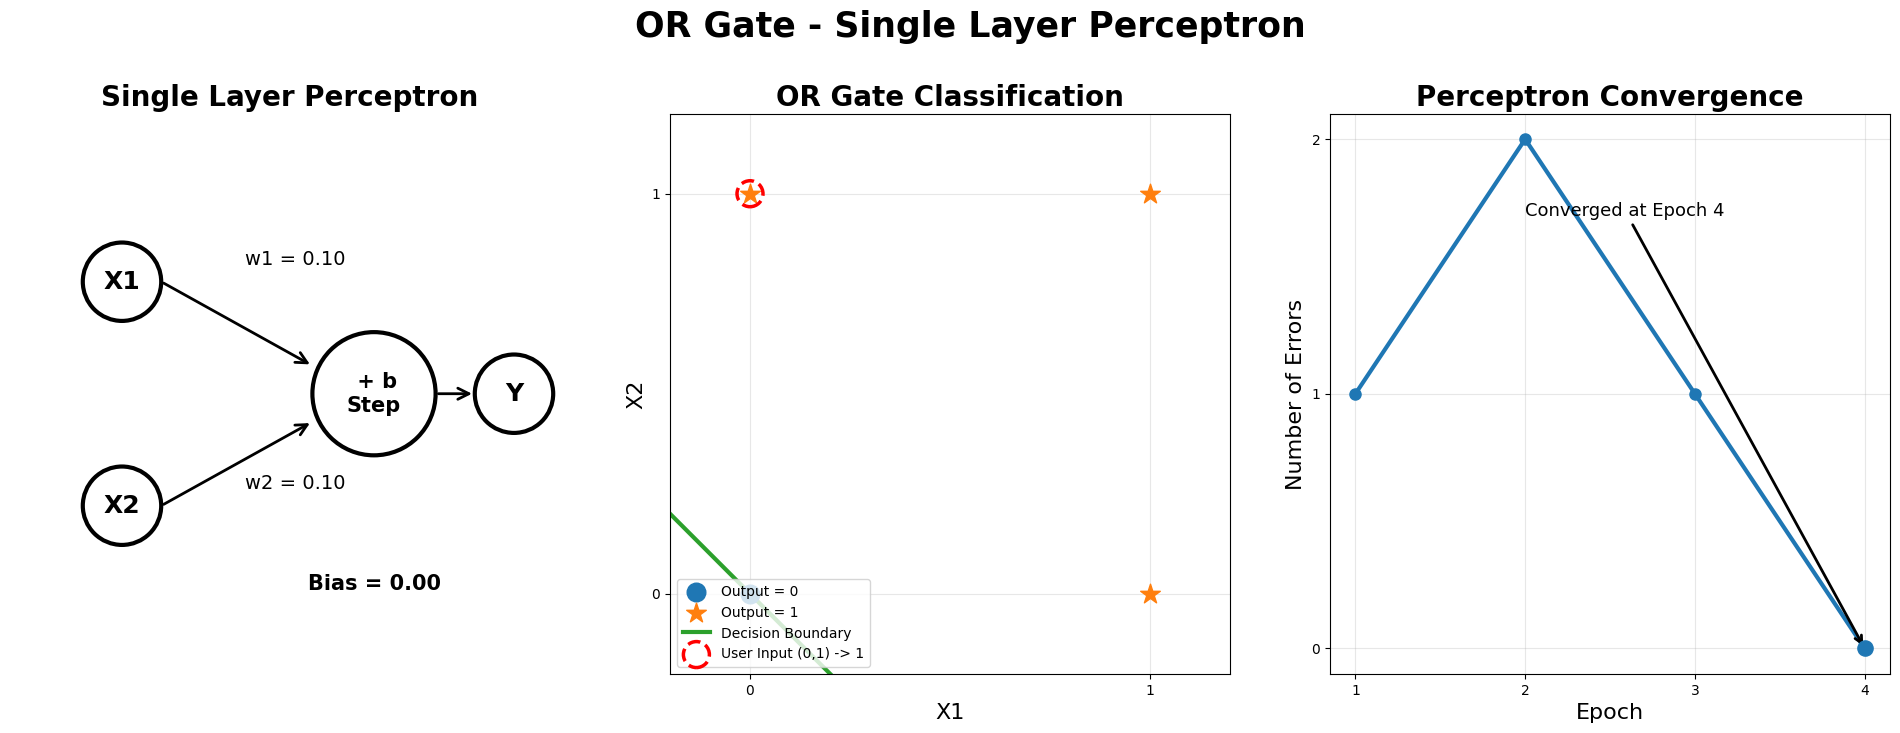

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# =========================================================
# 1. OR GATE TRAINING DATA
# =========================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 1, 1, 1])

# =========================================================
# 2. INITIALIZE WEIGHTS AND BIAS
# =========================================================

weights = np.array([0.0, 0.0])
bias = 0.0

learning_rate = 0.1
max_epochs = 20

# =========================================================
# 3. STEP ACTIVATION FUNCTION
# =========================================================

def activation(z):
    return 1 if z > 0 else 0

# =========================================================
# 4. PERCEPTRON TRAINING
# =========================================================

error_history = []

for epoch in range(max_epochs):
    errors = 0
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        prediction = activation(z)
        error = y[i] - prediction

        if error != 0:
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error
            errors += 1

    error_history.append(errors)

    print(
        f"Epoch {epoch + 1}: "
        f"Weights = {weights}, "
        f"Bias = {bias:.2f}, "
        f"Errors = {errors}"
    )

    if errors == 0:
        print("\nPerceptron converged!")
        print(f"Converged after {epoch + 1} epochs.")
        break
else:
    print("\nPerceptron did NOT converge within the maximum epochs!")

# =========================================================
# 5. USER INPUT
# =========================================================

print("\n==============================")
print("OR GATE PREDICTION")
print("==============================")

x1 = float(input("Enter X1 (0 or 1): "))
x2 = float(input("Enter X2 (0 or 1): "))

user_input = np.array([x1, x2])
z_user = np.dot(user_input, weights) + bias
user_prediction = activation(z_user)

# =========================================================
# 6. CREATE FIGURE
# =========================================================

fig = plt.figure(figsize=(20, 8))

# =========================================================
# 7. PERCEPTRON ARCHITECTURE DIAGRAM
# =========================================================

ax1 = fig.add_axes([0.02, 0.15, 0.28, 0.7])
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis("off")
ax1.set_title("Single Layer Perceptron", fontsize=20, fontweight="bold")

input_positions = [(2, 7), (2, 3)]
input_labels = ["X1", "X2"]

for (x, y_pos), label in zip(input_positions, input_labels):
    circle = Circle((x, y_pos), 0.7, fill=False, linewidth=3)
    ax1.add_patch(circle)
    ax1.text(x, y_pos, label, ha="center", va="center", fontsize=18, fontweight="bold")

ax1.text(4.2, 7.3, f"w1 = {weights[0]:.2f}", fontsize=14)
ax1.text(4.2, 3.3, f"w2 = {weights[1]:.2f}", fontsize=14)

neuron = Circle((6.5, 5), 1.1, fill=False, linewidth=3)
ax1.add_patch(neuron)
ax1.text(6.5, 5, " + b\nStep", ha="center", va="center", fontsize=15, fontweight="bold")

output = Circle((9, 5), 0.7, fill=False, linewidth=3)
ax1.add_patch(output)
ax1.text(9, 5, "Y", ha="center", va="center", fontsize=18, fontweight="bold")

arrow1 = FancyArrowPatch((2.7, 7), (5.4, 5.5), arrowstyle="->", mutation_scale=20, linewidth=2)
arrow2 = FancyArrowPatch((2.7, 3), (5.4, 4.5), arrowstyle="->", mutation_scale=20, linewidth=2)
arrow3 = FancyArrowPatch((7.6, 5), (8.3, 5), arrowstyle="->", mutation_scale=20, linewidth=2)

ax1.add_patch(arrow1)
ax1.add_patch(arrow2)
ax1.add_patch(arrow3)

ax1.text(6.5, 1.5, f"Bias = {bias:.2f}", ha="center", fontsize=15, fontweight="bold")

# =========================================================
# 8. OR GATE CLASSIFICATION GRAPH
# =========================================================

ax2 = fig.add_axes([0.35, 0.15, 0.28, 0.7])

class_0 = X[y == 0]
class_1 = X[y == 1]

ax2.scatter(class_0[:, 0], class_0[:, 1], s=180, marker="o", label="Output = 0", zorder=3)
ax2.scatter(class_1[:, 0], class_1[:, 1], s=220, marker="*", label="Output = 1", zorder=3)

# =========================================================
# 9. FINAL DECISION BOUNDARY
# =========================================================

x_boundary = np.linspace(-0.2, 1.2, 100)

if abs(weights[1]) > 1e-10:
    y_boundary = -(weights[0] * x_boundary + bias) / weights[1]
    ax2.plot(x_boundary, y_boundary, linewidth=3, label="Decision Boundary", color="tab:green", zorder=2)
elif abs(weights[0]) > 1e-10:
    x_vert = -bias / weights[0]
    ax2.axvline(x=x_vert, linewidth=3, label="Decision Boundary", color="tab:green", zorder=2)

# =========================================================
# 10. MARK USER INPUT
# =========================================================

ax2.scatter(
    x1, x2, s=350, facecolors="none", edgecolors="red", linewidths=2.5, linestyle="--",
    label=f"User Input ({x1:.0f},{x2:.0f}) -> {user_prediction}", zorder=4
)

# =========================================================
# 11. GRAPH FORMATTING
# =========================================================

ax2.set_title("OR Gate Classification", fontsize=20, fontweight="bold")
ax2.set_xlabel("X1", fontsize=16)
ax2.set_ylabel("X2", fontsize=16)
ax2.set_xlim(-0.2, 1.2)
ax2.set_ylim(-0.2, 1.2)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, loc="lower left")

# =========================================================
# 12. CONVERGENCE GRAPH
# =========================================================

ax3 = fig.add_axes([0.68, 0.15, 0.28, 0.7])

epochs = range(1, len(error_history) + 1)

ax3.plot(epochs, error_history, marker="o", linewidth=3, markersize=8)
ax3.set_title("Perceptron Convergence", fontsize=20, fontweight="bold")
ax3.set_xlabel("Epoch", fontsize=16)
ax3.set_ylabel("Number of Errors", fontsize=16)
ax3.set_xticks(list(epochs))
ax3.set_yticks(range(0, max(error_history) + 1))
ax3.grid(True, alpha=0.3)

# =========================================================
# 13. MARK CONVERGENCE POINT
# =========================================================

if error_history[-1] == 0:
    convergence_epoch = len(error_history)
    ax3.scatter(convergence_epoch, 0, s=120, zorder=5)
    ax3.annotate(
        f"Converged at Epoch {convergence_epoch}",
        xy=(convergence_epoch, 0),
        xytext=(max(1, convergence_epoch - 2), max(error_history) * 0.6 + 0.5),
        fontsize=13,
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )

# =========================================================
# 14. MAIN TITLE
# =========================================================

fig.suptitle("OR Gate - Single Layer Perceptron", fontsize=25, fontweight="bold")

plt.show()